**IMAGES**

**CNN**

In [3]:
pip install torch torchvision scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, random, math, pathlib
from pathlib import Path

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
from tqdm.notebook import tqdm

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print("PyTorch:", torch.__version__)

PyTorch: 2.8.0+cpu


In [57]:
df = pd.read_pickle("../data/skin-lesion-data/default.pickle")
df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,<NA>,<NA>,NaN,NaN,8,<NA>,NaN,<NA>,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,<NA>,<NA>,NaN,NaN,77,<NA>,NaN,<NA>,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,<NA>,<NA>,NaN,NaN,75,<NA>,NaN,<NA>,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [58]:
print(df['diagnostic'].unique())

['NEV', 'BCC', 'ACK', 'SEK', 'SCC', 'MEL']
Categories (6, object): ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [59]:
#Malignant = 1, benign = 0
df = df.copy()
df['diagnostic'] = df['diagnostic'].astype(str).str.upper()
malignant = ["BCC","MEL","SCC"] 
df['label'] = df['diagnostic'].apply(lambda x: "malignant" if x in malignant else "benign")
df['label_num'] = df['label'].map({"benign":0, "malignant":1})
print(df[['img_id','diagnostic','label','label_num']].head())
print("\nCounts:\n", df['label'].value_counts())

                  img_id diagnostic      label  label_num
0  PAT_1516_1765_530.png        NEV     benign          0
1     PAT_46_881_939.png        BCC  malignant          1
2  PAT_1545_1867_547.png        ACK     benign          0
3  PAT_1989_4061_934.png        ACK     benign          0
4   PAT_684_1302_588.png        BCC  malignant          1

Counts:
 label
benign       1209
malignant    1089
Name: count, dtype: int64


In [60]:
print(os.getcwd())

C:\Users\mercy\Heriot- Watt University\MODULES\Data Mining & Machine Learning\Course Work\group-coursework-meddm\notebooks


In [61]:
from pathlib import Path

root_dirs = [
    Path("../data/skin-lesion-data/images/imgs_part_1"),
    Path("../data/skin-lesion-data/images/imgs_part_2"),
    Path("../data/skin-lesion-data/images/imgs_part_3")
]

# Check again:
for p in root_dirs:
    print(p.resolve(), "-> exists:", p.exists())

C:\Users\mercy\Heriot- Watt University\MODULES\Data Mining & Machine Learning\Course Work\group-coursework-meddm\data\skin-lesion-data\images\imgs_part_1 -> exists: True
C:\Users\mercy\Heriot- Watt University\MODULES\Data Mining & Machine Learning\Course Work\group-coursework-meddm\data\skin-lesion-data\images\imgs_part_2 -> exists: True
C:\Users\mercy\Heriot- Watt University\MODULES\Data Mining & Machine Learning\Course Work\group-coursework-meddm\data\skin-lesion-data\images\imgs_part_3 -> exists: True


In [62]:
# Step 2: test if metadata img_id values match actual image files
from collections import Counter

def find_file(fname):
    """Search for an image filename inside all 3 folders."""
    for p in root_dirs:
        candidate = p / fname
        if candidate.is_file():
            return candidate
    return None

missing = []
found = 0
n_test = min(200, len(df))  # check first 200 entries
for i in range(n_test):
    img_name = f"{df.iloc[i]['img_id']}.png"
    if find_file(img_name):
        found += 1
    else:
        missing.append(img_name)

print(f"Checked {n_test} rows — Found: {found}, Missing: {len(missing)}")
print("First 10 missing (if any):", missing[:10])

Checked 200 rows — Found: 0, Missing: 200
First 10 missing (if any): ['PAT_1516_1765_530.png.png', 'PAT_46_881_939.png.png', 'PAT_1545_1867_547.png.png', 'PAT_1989_4061_934.png.png', 'PAT_684_1302_588.png.png', 'PAT_1549_1882_230.png.png', 'PAT_778_1471_835.png.png', 'PAT_117_179_983.png.png', 'PAT_1995_4080_695.png.png', 'PAT_705_4015_413.png.png']


In [63]:
df["img_id"].head(10)

0    PAT_1516_1765_530.png
1       PAT_46_881_939.png
2    PAT_1545_1867_547.png
3    PAT_1989_4061_934.png
4     PAT_684_1302_588.png
5    PAT_1549_1882_230.png
6     PAT_778_1471_835.png
7      PAT_117_179_983.png
8    PAT_1995_4080_695.png
9     PAT_705_4015_413.png
Name: img_id, dtype: string

In [64]:
#Going through every image name in tabula dataset, look in all the 3 folders to check whether all 2298 images exist. 
def find_file(fname):
    for p in root_dirs:#going through all the 3 folders
        candidate = p / fname
        if candidate.is_file():
            return candidate
    return None

missing = []
found = 0

for i in range(len(df)):# going through the entire dataframe
    img_name = str(df.iloc[i]["img_id"]).strip() 
    if find_file(img_name):
        found += 1
    else:
        missing.append(img_name)

print(f"Checked {len(df)} rows — Found: {found}, Missing: {len(missing)}")

Checked 2298 rows — Found: 2298, Missing: 0


In [65]:
#Transformations; resizing and normalisation 
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),         #Resizing; 128x128 pixels
    transforms.RandomHorizontalFlip(),     #augmentating - flips images randomly
    transforms.RandomRotation(10),         #Rotate slightly+-10
    transforms.ToTensor(),                 #Convert from PIL image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406],  #Normalisation; using commonly used default values
                         [0.229, 0.224, 0.225])
])

#Validation/test sets - no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [66]:
#Pytorch dataset class
class SkinLesionDataset(Dataset):
    def __init__(self, df, root_dirs, transform=None):
        self.df = df.reset_index(drop=True)  
        self.root_dirs = root_dirs          
        self.transform = transform           

    def __len__(self):
        return len(self.df)#Return the number of samples (rows)

    def _find_path(self, fname):
        for rd in self.root_dirs:#Find which folder contains the image file
            path = rd / fname
            if path.is_file():
                return path
        return None  

    def __getitem__(self, idx):
        row = self.df.iloc[idx]#Return (image_tensor, label) for the idx-th sample
        img_name = str(row['img_id']).strip()#e.g.'PAT_1516_1765_530.png'
        label = int(row['label_num'])            

        path = self._find_path(img_name)
        if path is None:
            raise FileNotFoundError(f"Image not found: {img_name}")

        # Open and process image
        img = Image.open(path).convert("RGB")#ensures 3 color channels
        if self.transform:
            img = self.transform(img)#apply preprocessing

        return img, label

In [67]:
#Data spliting; training and testing data
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label_num'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_num'], random_state=42)

print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))

Train: 1838 Validation: 230 Test: 230


In [68]:
#Patient-level split (no patient appears in more than one set)

#First split: 80% train and 20% temp
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['patient_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

#Second split;spliting temp into 2; validation and testing set
gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx_rel, test_idx_rel = next(gss2.split(temp_df, groups=temp_df['patient_id']))
val_df = temp_df.iloc[val_idx_rel].reset_index(drop=True)
test_df = temp_df.iloc[test_idx_rel].reset_index(drop=True)

print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))

Train: 1837 Validation: 233 Test: 228


In [69]:
#Split check to check whether there is patient level leakage, if any patient appears in more than one split
train_patients = set(train_df['patient_id'])
val_patients   = set(val_df['patient_id'])
test_patients  = set(test_df['patient_id'])

print("Overlap train/val:", train_patients & val_patients)
print("Overlap train/test:", train_patients & test_patients)
print("Overlap val/test:", val_patients & test_patients)


Overlap train/val: set()
Overlap train/test: set()
Overlap val/test: set()


In [70]:
#Class balance check
print("Train class counts:\n", train_df['label_num'].value_counts(normalize=True))
print("Val class counts:\n", val_df['label_num'].value_counts(normalize=True))
print("Test class counts:\n", test_df['label_num'].value_counts(normalize=True))

Train class counts:
 label_num
0    0.53239
1    0.46761
Name: proportion, dtype: float64
Val class counts:
 label_num
0    0.51073
1    0.48927
Name: proportion, dtype: float64
Test class counts:
 label_num
1    0.508772
0    0.491228
Name: proportion, dtype: float64


In [71]:
train_dataset = SkinLesionDataset(train_df, root_dirs, transform=train_transform)
val_dataset   = SkinLesionDataset(val_df,   root_dirs, transform=eval_transform)
test_dataset  = SkinLesionDataset(test_df,  root_dirs, transform=eval_transform)

In [72]:
#Dataloaders to feed CNN
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Batch shape: torch.Size([32, 3, 128, 128])
Labels: [0, 1, 0, 0, 1, 0, 1, 1]


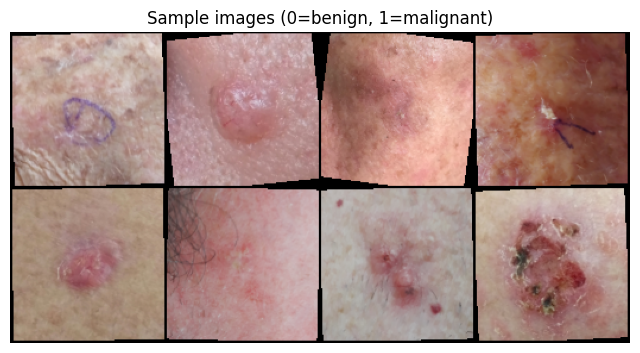

In [73]:
#Visualising images
#import matplotlib.pyplot as plt
#import torchvision

#get a batch of images and labels
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels:", labels[:8].tolist())

#unnormalize (reverse normalization for display)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
images_unnorm = images * std + mean

grid = torchvision.utils.make_grid(images_unnorm[:8], nrow=4)
plt.figure(figsize=(8,6))
plt.imshow(grid.permute(1,2,0).clip(0,1))
plt.title("Sample images (0=benign, 1=malignant)")
plt.axis("off")
plt.show()

In [74]:
#CNN Structure; learns to extract visual patterns from images and decide if they are benign or malignant
class SkinLesionCNN(nn.Module):
    def __init__(self):
        super(SkinLesionCNN, self).__init__()
        
        #Convolutional block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)#colours,filters, kernel size, keeps output size same
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        #Convolutional block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        
        #Convolutional block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        
        #Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.5)
        
        #Fully connected layers (dense) - convert 3D into 1D vector
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  #manually calculated; image is 128x128
        self.fc2 = nn.Linear(256, 2)  #output 2 classes; benign, malignant
    
    def forward(self, x):
        #defining how data flows through the layers; Conv., ReLU & Pool 
        #each block learns more complex feature while reducing the size
        x = self.pool(F.relu(self.conv1(x)))  #128x128 → 64x64
        x = self.pool(F.relu(self.conv2(x)))  #64x64 → 32x32
        x = self.pool(F.relu(self.conv3(x)))  #32x32 → 16x16
        
        #Flatten (convert 3D tensor to 1D for dense layers)
        x = x.view(-1, 128 * 16 * 16)
        
        #Fully connected layers & dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [75]:
#Verifying model structure
model = SkinLesionCNN()
print(model)

SkinLesionCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


Using device: cpu
Class weights: [0.93916155 1.06926659]

Epoch 1/12


  0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.6928  Train acc: 0.5433
Val   loss: 0.6609  Val   acc: 0.6824
Saved best model (val acc improved)

Epoch 2/12


  0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.6156  Train acc: 0.6663
Val   loss: 0.5946  Val   acc: 0.7082
Saved best model (val acc improved)

Epoch 3/12


...

Train loss: 0.4819  Train acc: 0.7659
Val   loss: 0.5278  Val   acc: 0.7468

Epoch 11/12


  0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.4860  Train acc: 0.7746
Val   loss: 0.5214  Val   acc: 0.7768

Epoch 12/12


  0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.4730  Train acc: 0.7768
Val   loss: 0.5163  Val   acc: 0.7554

Loading best model and evaluating on test set...
Test loss: 0.5270  Test acc: 0.7325
Confusion matrix:
 [[69 43]
 [18 98]]

Classification report:
               precision    recall  f1-score   support

      benign       0.79      0.62      0.69       112
   malignant       0.70      0.84      0.76       116

    accuracy                           0.73       228
   macro avg       0.74      0.73      0.73       228
weighted avg       0.74      0.73      0.73       228



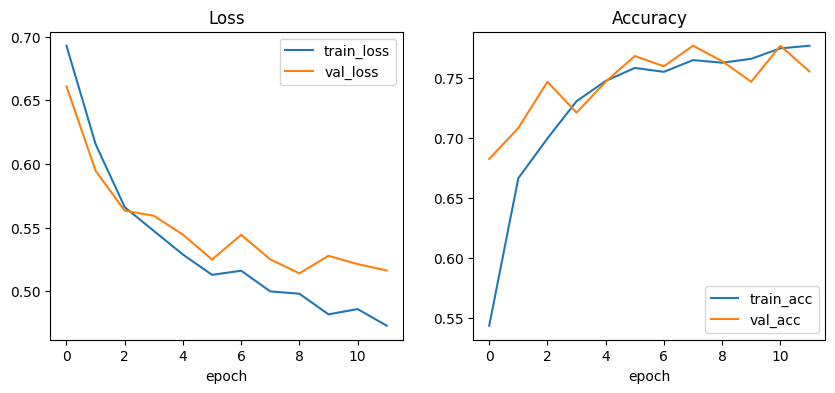

In [76]:
# Training & evaluation 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SkinLesionCNN().to(device)   #move model to GPU if availabl


#Class weights to handle any class imbalance
try:
    classes = np.array([0,1])
    from sklearn.utils.class_weight import compute_class_weight
    weights = compute_class_weight("balanced", classes=classes, y=train_df['label_num'])
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
    print("Class weights:", weights)
    criterion = nn.CrossEntropyLoss(weight=class_weights)  
except Exception as e:
    #fallback to unweighted loss if compute fails
    print("Could not compute class weights, using unweighted loss:", e)
    criterion = nn.CrossEntropyLoss()

#optimizer & scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#optional scheduler to reduce LR when validation stalls

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

#helper functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()                      #set model to training mode (dropout on)
    running_loss = 0.0
    all_preds = []
    all_labels = []
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)                     #forward pass 
        loss = criterion(logits, labels)         #CrossEntropy expects
        loss.backward()                          #compute gradients
        optimizer.step()                         #update weights

        running_loss += loss.item() * imgs.size(0)  #accumulate loss
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        pbar.set_description(f"train loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()                       #eval mode (dropout off)
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, dtype=torch.long, non_blocking=True)

            logits = model(imgs)
            loss = criterion(logits, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds

#training loop
n_epochs = 12
best_val_acc = 0.0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

for epoch in range(1, n_epochs+1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    # scheduler based on validation accuracy or val_loss
    scheduler.step(val_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train loss: {tr_loss:.4f}  Train acc: {tr_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f}  Val   acc: {val_acc:.4f}")

    #save best model based on val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_skinlesion_cnn.pth")
        print("Saved best model (val acc improved)")

#Load best model & test evaluation
print("\nLoading best model and evaluating on test set...")
model.load_state_dict(torch.load("best_skinlesion_cnn.pth"))
test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}")

#Confusion matrix and classification report
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(test_labels, test_preds, target_names=["benign","malignant"]))

#plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("epoch")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [52]:
#Sensitivity (how good in detecting cancer) & specificity (how good in avaoiding false alarms)
cm = confusion_matrix(test_labels, test_preds)
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

Sensitivity: 0.767
Specificity: 0.777


In [53]:
print(f"Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}")


Test loss: 0.5100  Test acc: 0.7719


CNN metrics, plot, ROC–AUC

Sensitivity (Recall for malignant): 0.767
Specificity (Recall for benign): 0.777
ROC-AUC: 0.836


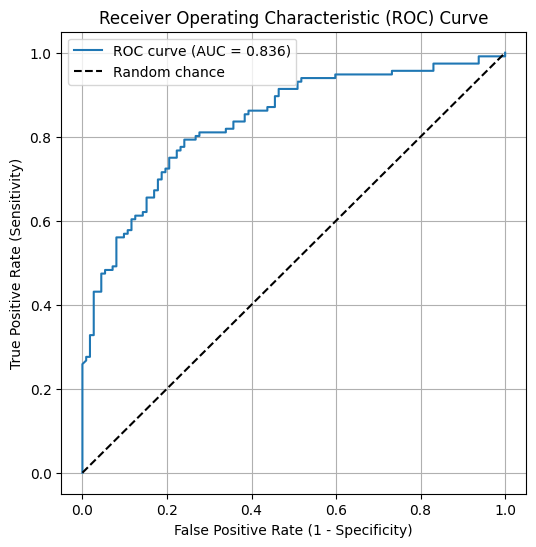

In [54]:
#Confusion matrix
#cm = confusion_matrix(test_labels, test_preds)
#tn, fp, fn, tp = cm.ravel()

#Sensitivity and specificity
#sensitivity = tp / (tp + fn)
#specificity = tn / (tn + fp)
#print(f"Sensitivity (Recall for malignant): {sensitivity:.3f}")
#print(f"Specificity (Recall for benign): {specificity:.3f}")

#ROC curve and AUC 
#get prediction probabilities instead of hard classes
model.eval()
all_probs = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1]  #probability of class 1 (malignant)
        all_probs.extend(probs.cpu().numpy())

auc = roc_auc_score(test_labels, all_probs)
fpr, tpr, _ = roc_curve(test_labels, all_probs)

print(f"ROC-AUC: {auc:.3f}")#how well the model separates classes in general

#ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()